# H2 ?? ?? ?? ?? ??

H1 ?? ?? ?? ??? ???? ?? ?? ? ?? ?? ??? ???? ????. ?? ??? ??? ??? `run_analysis.py`? ?? ???? ??? ?? ??? ???? ?? ????.

In [1]:
from pathlib import Path
import json
import subprocess
import sys

import pandas as pd
from IPython.display import Image, Markdown, display

root = Path.cwd()
h2_dir = root / "h2_distribution" if (root / "h2_distribution").exists() else root
subprocess.run([sys.executable, str(h2_dir / "run_analysis.py")], check=True)
results = json.loads((h2_dir / "results.json").read_text(encoding="utf-8"))

## ?? ??

?? ??? ?? ?? `is_current_parking_candidate`? ? ???? ????. `p`? ???? ????? Monte Carlo ??? ???? ??? ??? ????.

In [2]:
primary = results["labels"][0]
summary = pd.DataFrame([
    {
        "dimension": test["dimension"],
        "chi2": test["chi2"],
        "df": test["dof"],
        "p": test["p_value"],
        "monte_carlo_p": test["monte_carlo_p_value"],
        "holm_adjusted_p": test["holm_adjusted_p_value"],
        "min_expected": test["min_expected_frequency"],
        "cramers_v": test["cramers_v"],
    }
    for test in primary["tests"]
])
display(Markdown(f"?? ?? **{primary['n']:,}?**, ?? ?? **{primary['candidate_n']}? ({primary['candidate_rate'] * 100:.2f}%)**"))
display(summary.round(4))

?? ?? **1,940?**, ?? ?? **35? (1.80%)**

,dimension,chi2,df,p,monte_carlo_p,holm_adjusted_p,min_expected,cramers_v
0,level_band,6.9948,2,0.0303,0.0273,0.0606,11.0773,0.0600
1,class_group,3.0339,4,0.5522,0.5690,0.5522,6.8918,0.0395


## ?? ?? ???

??? ??? ??? ?? ?? odds ratio? ?? ??? ????.

,category,n,candidate_n,candidate_rate_pct,candidate_standardized_residual,odds_ratio_vs_rest,odds_ratio_ci95
0,270-279,614,9,1.466,-0.624,0.744,"[0.3464154808169949, 1.5970443859521808]"
1,280-285,656,19,2.896,2.083,2.364,"[1.207377851828213, 4.627896888616145]"
2,286-290,670,7,1.045,-1.463,0.468,"[0.2034794789716235, 1.077892711467923]"


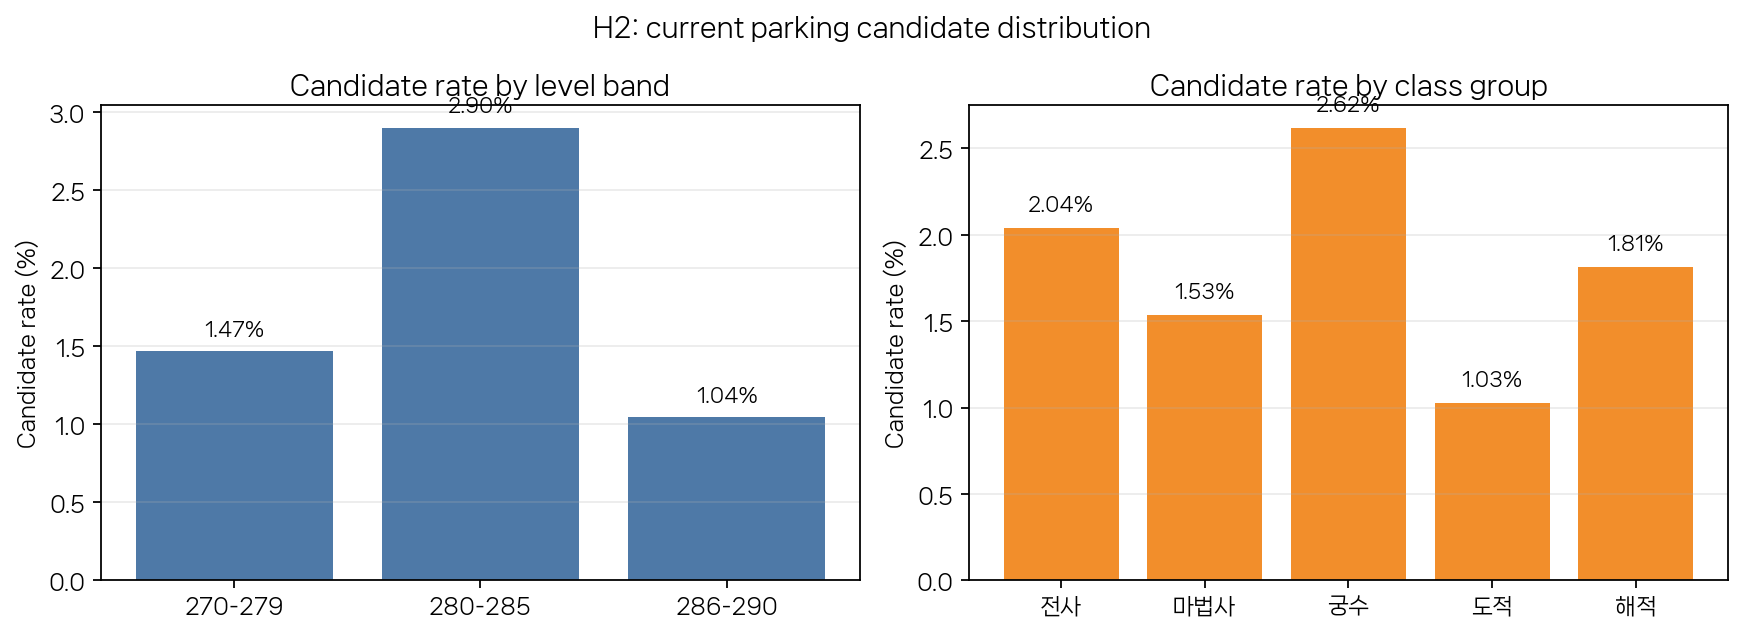

In [3]:
level_rows = pd.DataFrame(primary["tests"][0]["categories"])
level_rows["candidate_rate_pct"] = level_rows["candidate_rate"] * 100
display(level_rows[[
    "category", "n", "candidate_n", "candidate_rate_pct",
    "candidate_standardized_residual", "odds_ratio_vs_rest", "odds_ratio_ci95"
]].round(3))
display(Image(filename=str(h2_dir / "figures" / "candidate_distribution.png")))

## ??

?? ??? ?? ?? ?? ??? `p < 0.05`? ?? ??? ???? `280-285` ??? ?? ??? ????? ??. ?? ?? ??? ???? ???. ?? Holm ??? ??? ?? ??? ????? ???? ???? ?? ????? ????, ?? ?? ???? ????? ?? ??? ?? ??? ????. ?? ??? `RESULTS.md`? ????.